# ZigZag Regime Detection for the S&P 500

This notebook uses a ZigZag algorithm with a configurable percentage reversal filter to capture major market swings.

Why this fits regime detection:
- it measures reversals in percentage terms rather than raw dollars
- it keeps only confirmed swing highs and lows once price reverses by a chosen threshold
- a 5% filter is more reactive, while a 10% filter is stiffer and focuses on larger regime turns
- the output is a simple reusable polyline of market pivots


In [16]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

TICKER = "^GSPC"
START_DATE = "2014-01-01"
END_DATE = None
REVERSAL_PCT = 0.10


def load_data(ticker: str = TICKER, start: str = START_DATE, end: str | None = END_DATE) -> list[tuple[pd.Timestamp, float]]:
    history = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if history.empty:
        raise ValueError(f"No price history returned for {ticker}.")

    close = history["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.squeeze("columns")
    if not isinstance(close, pd.Series):
        raise TypeError("Expected the Close field to resolve to a pandas Series.")

    close = close.dropna().sort_index()
    return list(close.items())


raw_data = load_data()
raw_data[:5]


[(Timestamp('2014-01-02 00:00:00'), 1831.97998046875),
 (Timestamp('2014-01-03 00:00:00'), 1831.3699951171875),
 (Timestamp('2014-01-06 00:00:00'), 1826.77001953125),
 (Timestamp('2014-01-07 00:00:00'), 1837.8800048828125),
 (Timestamp('2014-01-08 00:00:00'), 1837.489990234375)]

In [17]:
price_frame = pd.DataFrame(raw_data, columns=["date", "close"]).sort_values("date").dropna()
price_frame["close"] = pd.to_numeric(price_frame["close"], errors="coerce")
price_frame = price_frame.dropna(subset=["close"]).reset_index(drop=True)
price_frame["close_processed"] = price_frame["close"].interpolate(limit_direction="both")

series_dates = price_frame["date"].to_numpy()
series_prices = price_frame["close_processed"].to_numpy(dtype=float)

price_frame.tail()


,date,close,close_processed
3086,2026-04-13,6886.240234,6886.240234
3087,2026-04-14,6967.379883,6967.379883
3088,2026-04-15,7022.950195,7022.950195
3089,2026-04-16,7041.279785,7041.279785
3090,2026-04-17,7114.430176,7114.430176


In [18]:
@dataclass
class ZigZagFit:
    nodes: pd.DataFrame
    pct_change_to_next: pd.Series
    node_indices: np.ndarray
    reversal_pct: float


def fit_zigzag(dates: np.ndarray, prices: np.ndarray, reversal_pct: float) -> ZigZagFit:
    values = np.asarray(prices, dtype=float)
    if values.size < 2:
        raise ValueError("Need at least two observations for ZigZag")
    if reversal_pct <= 0:
        raise ValueError("reversal_pct must be positive")

    threshold = float(reversal_pct)
    pivots = [0]
    direction = 0
    candidate_index = 0

    for idx in range(1, values.size):
        current = values[idx]

        if direction == 0:
            move_from_start = current / values[pivots[-1]] - 1.0
            if move_from_start >= threshold:
                direction = 1
                candidate_index = idx
            elif move_from_start <= -threshold:
                direction = -1
                candidate_index = idx
            else:
                if current >= values[candidate_index] or current <= values[candidate_index]:
                    candidate_index = idx
            continue

        if direction == 1:
            if current >= values[candidate_index]:
                candidate_index = idx
                continue

            reversal = current / values[candidate_index] - 1.0
            if reversal <= -threshold:
                pivots.append(candidate_index)
                direction = -1
                candidate_index = idx
            continue

        if current <= values[candidate_index]:
            candidate_index = idx
            continue

        reversal = current / values[candidate_index] - 1.0
        if reversal >= threshold:
            pivots.append(candidate_index)
            direction = 1
            candidate_index = idx

    if candidate_index != pivots[-1]:
        pivots.append(candidate_index)
    if pivots[-1] != values.size - 1:
        pivots.append(values.size - 1)

    node_indices = np.array(sorted(set(pivots)), dtype=int)
    nodes = pd.DataFrame(
        {
            "date": pd.to_datetime(dates[node_indices]),
            "price": values[node_indices],
        }
    )
    nodes["pct_change_from_prior"] = nodes["price"].pct_change()

    pct_change_to_next = pd.Series(
        np.diff(nodes["price"]) / nodes["price"].to_numpy()[:-1],
        index=nodes.index[:-1],
        name="pct_change_to_next",
    )

    return ZigZagFit(
        nodes=nodes,
        pct_change_to_next=pct_change_to_next,
        node_indices=node_indices,
        reversal_pct=threshold,
    )


In [19]:
fit_result = fit_zigzag(series_dates, series_prices, reversal_pct=REVERSAL_PCT)

result_table = fit_result.nodes.copy()
result_table["pct_change_to_next"] = fit_result.pct_change_to_next.reindex(result_table.index)

print(f"Ticker: {TICKER}")
print(f"Observations: {len(series_prices)}")
print(f"Reversal filter: {REVERSAL_PCT:.0%}")
print(f"Detected nodes: {len(fit_result.node_indices)}")
print(f"Detected segments: {len(fit_result.node_indices) - 1}")

result_table


Ticker: ^GSPC
Observations: 3091
Reversal filter: 10%
Detected nodes: 22
Detected segments: 21


,date,price,pct_change_from_prior,pct_change_to_next
0,2014-01-02,1831.979980,NaN,0.163124
1,2015-05-21,2130.820068,0.163124,-0.123525
2,2015-08-25,1867.609985,-0.123525,0.129674
3,2015-11-03,2109.790039,0.129674,-0.133051
4,2016-02-11,1829.079956,-0.133051,0.570664
5,2018-01-26,2872.870117,0.570664,-0.101595
6,2018-02-08,2581.000000,-0.101595,0.135509
7,2018-09-20,2930.750000,0.135509,-0.197782
8,2018-12-24,2351.100098,-0.197782,0.440241
9,2020-02-19,3386.149902,0.440241,-0.339250


In [20]:
def build_zigzag_object(nodes: pd.DataFrame, ticker: str, reversal_pct: float) -> dict:
    segments = []
    for left, right in zip(nodes.iloc[:-1].itertuples(index=False), nodes.iloc[1:].itertuples(index=False)):
        pct_change = float(right.price / left.price - 1.0)
        segments.append(
            {
                "date_range": f"{left.date:%Y-%m-%d} -> {right.date:%Y-%m-%d}",
                "start_date": f"{left.date:%Y-%m-%d}",
                "end_date": f"{right.date:%Y-%m-%d}",
                "start_price": round(float(left.price), 2),
                "end_price": round(float(right.price), 2),
                "pct_change": round(pct_change, 4),
                "pct_change_label": f"{pct_change:+.2%}",
                "direction": "up" if pct_change > 0 else "down",
                "trading_days": int((nodes["date"] == right.date).idxmax() - (nodes["date"] == left.date).idxmax()),
            }
        )

    return {
        "ticker": ticker,
        "reversal_pct": reversal_pct,
        "start_date": f"{nodes.iloc[0]['date']:%Y-%m-%d}",
        "end_date": f"{nodes.iloc[-1]['date']:%Y-%m-%d}",
        "node_count": int(len(nodes)),
        "segment_count": int(len(segments)),
        "segments": segments,
    }


zigzag_object = build_zigzag_object(fit_result.nodes, TICKER, REVERSAL_PCT)
zigzag_object


{'ticker': '^GSPC',
 'reversal_pct': 0.1,
 'start_date': '2014-01-02',
 'end_date': '2026-04-17',
 'node_count': 22,
 'segment_count': 21,
 'segments': [{'date_range': '2014-01-02 -> 2015-05-21',
   'start_date': '2014-01-02',
   'end_date': '2015-05-21',
   'start_price': 1831.98,
   'end_price': 2130.82,
   'pct_change': 0.1631,
   'pct_change_label': '+16.31%',
   'direction': 'up',
   'trading_days': 1},
  {'date_range': '2015-05-21 -> 2015-08-25',
   'start_date': '2015-05-21',
   'end_date': '2015-08-25',
   'start_price': 2130.82,
   'end_price': 1867.61,
   'pct_change': -0.1235,
   'pct_change_label': '-12.35%',
   'direction': 'down',
   'trading_days': 1},
  {'date_range': '2015-08-25 -> 2015-11-03',
   'start_date': '2015-08-25',
   'end_date': '2015-11-03',
   'start_price': 1867.61,
   'end_price': 2109.79,
   'pct_change': 0.1297,
   'pct_change_label': '+12.97%',
   'direction': 'up',
   'trading_days': 1},
  {'date_range': '2015-11-03 -> 2016-02-11',
   'start_date': '

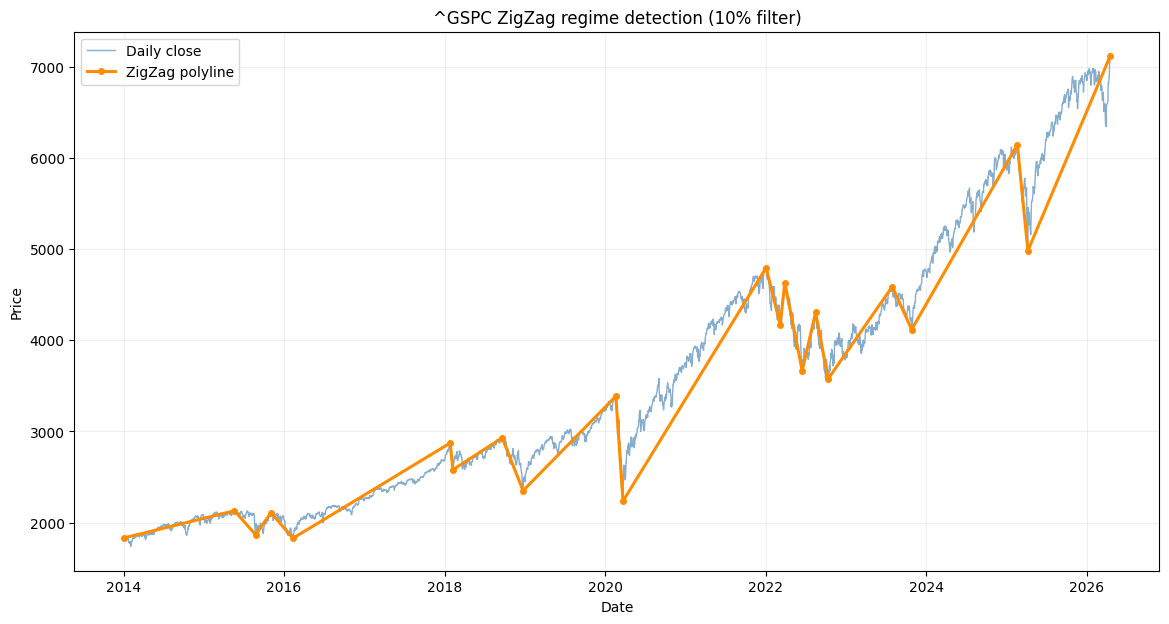

In [21]:
def plot_zigzag(dates: np.ndarray, values: np.ndarray, node_indices: np.ndarray, ticker: str, reversal_pct: float) -> None:
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(dates, values, label="Daily close", linewidth=1.0, color="steelblue", alpha=0.65)
    ax.plot(
        dates[node_indices],
        values[node_indices],
        color="darkorange",
        linewidth=2.2,
        marker="o",
        markersize=4,
        label="ZigZag polyline",
    )
    ax.set_title(f"{ticker} ZigZag regime detection ({reversal_pct:.0%} filter)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()


plot_zigzag(series_dates, series_prices, fit_result.node_indices, TICKER, REVERSAL_PCT)
